In [1]:
%load_ext google.colab.data_table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    import geopandas as gpd
    HAS_GEO = True
except ImportError:
    HAS_GEO = False
    print("deu erro no geopandas ze")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')


In [2]:
df = pd.read_csv('Tourism Quantity Data.csv')
df.head()

,País,Sigla,Continente,Region,IncomeGroup,Ano,Population,Arrivals,Receipts,Expenditures,Receipts for Travel Items,Expenditures for Travel Items,Receipts - % of Total Exports,Expenditures - % of Total Imports,Is_Territory
0,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2004,3026939.0,645000.0,7.560000e+08,6.690000e+08,7.350000e+08,6.420000e+08,60.49,23.13,False
1,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2005,3011487.0,748000.0,8.800000e+08,8.080000e+08,8.540000e+08,7.860000e+08,60.24,23.08,False
2,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2006,2992547.0,937000.0,1.057000e+09,9.890000e+08,1.012000e+09,9.650000e+08,56.54,24.28,False
3,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2007,2970017.0,1127000.0,1.479000e+09,1.331000e+09,1.378000e+09,1.268000e+09,60.01,24.91,False
4,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2008,2947314.0,1420000.0,1.850000e+09,1.644000e+09,1.715000e+09,1.555000e+09,56.36,24.43,False


# Feature Engineering

## 1. Eficiência do Turismo
**Variável:** Receita por turista (Receipts / Arrivals)

In [3]:
df['Receita_Turista'] = df['Receipts'] / df['Arrivals']

**Variável:** Gasto por turista (Expenditures / Arrivals)

In [4]:
df['Gasto_Turista'] = df['Expenditures'] / df['Arrivals']

## 2. Balança Turística
**Variável:** Diferença entre receitas e despesas (Receipts - Expenditures)

In [5]:
df['Receita_menos_Despesas'] = df['Receipts'] - df['Expenditures']

**Variável:** Razão entre receitas e despesas


In [6]:
df['Receita_Despesa'] = df['Receipts'] / df['Expenditures']

## 3. Intensidade Turística
**Variável:** Turistas por habitante (Arrivals / Population)

In [7]:
df['Turista_Habitante'] = df['Arrivals'] / df['Population']

## 4. Dependência do Turismo
**Variável:** Utilizar % de exportações provenientes do turismo

In [8]:
df['Dependencia_Media'] = df.groupby('País')['Receipts - % of Total Exports'].transform('mean')

## 5. Crescimento Temporal
**Variável:** Crescimento anual de Arrivals

In [9]:
df['Crescimento_Arrivals'] = df.groupby('País')['Arrivals'].pct_change()

**Variável:** Crescimento anual de Receipts

In [10]:
df['Crescimento_Receipts'] = df.groupby('País')['Receipts'].pct_change()

**Variável:** Crescimento acumulado no período

In [11]:
df['Cresc_Acumulado_Arrivals'] = df.groupby('País')['Arrivals'].transform(lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100)

## 6. Volatilidade
**Variável:** Desvio padrão de Arrivals ao longo do tempo por país

In [12]:
df['Volatilidade_Arrivals'] = df.groupby('País')['Arrivals'].transform('std')

## 7. Volatilidade
**Variável:** Classificar países em:

*   Turismo de massa
*   Turismo de alto valor
*   Perfil misto


In [13]:
m_hab = df['Turista_Habitante'].median()
m_rec = df['Receita_Turista'].median()

df['Perfil_Turistico'] = 'Perfil misto'

df.loc[(df['Turista_Habitante'] > m_hab) & (df['Receita_Turista'] < m_rec), 'Perfil_Turistico'] = 'Turismo de massa'
df.loc[(df['Receita_Turista'] > m_rec) & (df['Turista_Habitante'] < m_hab), 'Perfil_Turistico'] = 'Turismo de alto valor'

# Exploratory Data Analysis

## 1. Visão geral das variáveis criadas
Antes de olhar os tópicos, verificamos as estatísticas básicas (média, mediana, desvio padrão) das variáveis de FE.


In [15]:
fe_cols = [
    'Receita_Turista', 'Gasto_Turista', 'Receita_menos_Despesas',
    'Receita_Despesa', 'Turista_Habitante', 'Dependencia_Media',
    'Crescimento_Arrivals', 'Crescimento_Receipts',
    'Cresc_Acumulado_Arrivals', 'Volatilidade_Arrivals'
]

stats = df[fe_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Mín', 'Máx']
stats = stats.round(4)
display(stats)


,Média,Mediana,Desvio Padrão,Mín,Máx
Receita_Turista,9.670000e+02,7.617555e+02,9.297955e+02,2.825000e-01,8.377680e+03
Gasto_Turista,9.394944e+02,4.365252e+02,1.230627e+03,8.620700e+00,1.257692e+04
Receita_menos_Despesas,8.395426e+08,1.516000e+08,8.478335e+09,-5.228900e+10,8.590500e+10
Receita_Despesa,2.650400e+00,1.314900e+00,4.400800e+00,8.000000e-04,8.023080e+01
Turista_Habitante,2.144200e+00,3.694000e-01,6.829200e+00,6.000000e-04,6.822640e+01
Dependencia_Media,1.815630e+01,1.006530e+01,1.929110e+01,9.750000e-02,8.601530e+01
Crescimento_Arrivals,8.010000e-02,5.300000e-02,2.828000e-01,-8.389000e-01,9.564500e+00
Crescimento_Receipts,1.610000e-01,6.720000e-02,1.296200e+00,-9.978000e-01,4.200000e+01
Cresc_Acumulado_Arrivals,2.147321e+02,1.081553e+02,3.644713e+02,-7.155040e+01,2.878261e+03
Volatilidade_Arrivals,1.865960e+06,5.299616e+05,3.793379e+06,6.613838e+02,3.697692e+07


## 2. Distribuição de receita por turista
**Pergunta:** Como os países se distribuem em termos de receita por turista?


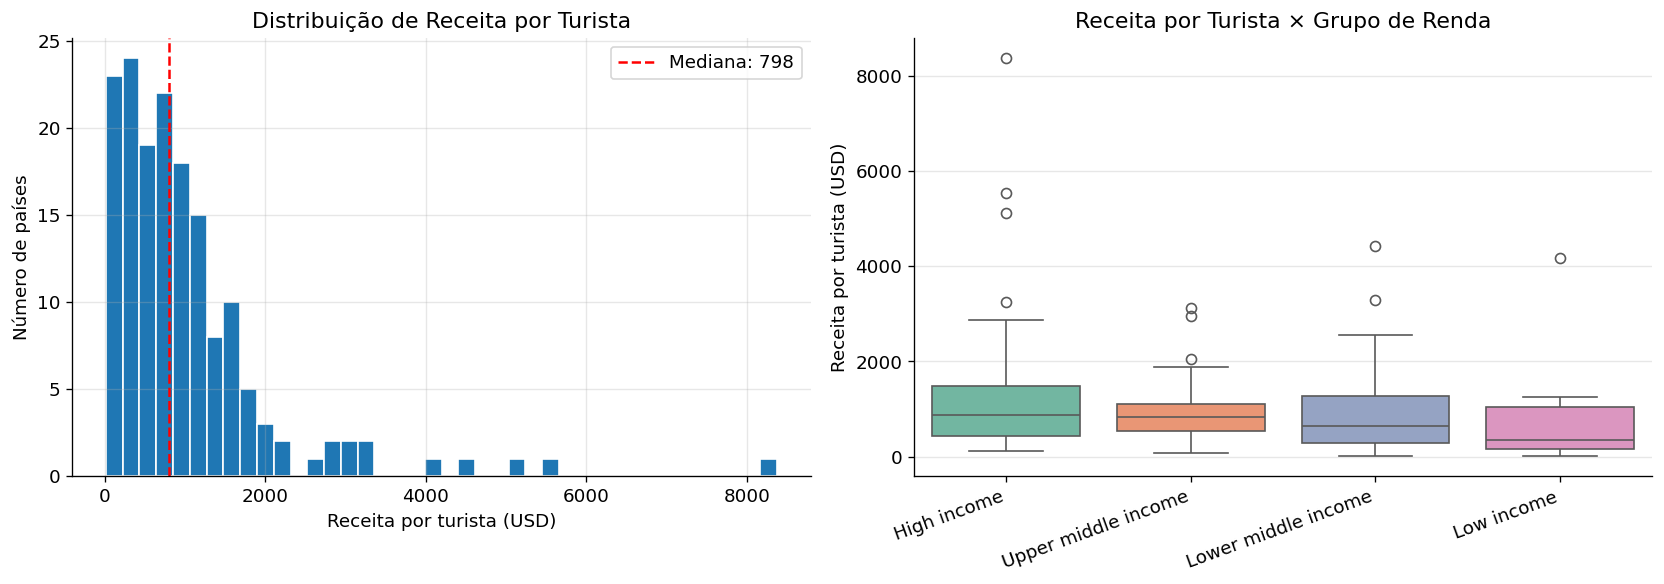


Estatísticas de Receita por Turista (último ano):
count     161.00
mean     1031.34
std      1091.65
min        12.25
25%       342.07
50%       797.65
75%      1263.92
max      8377.68


In [17]:
last_year = df.sort_values('Ano').groupby('País').last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(last_year['Receita_Turista'].dropna(), bins=40,
             color=PALETTE[0], edgecolor='white')
axes[0].axvline(last_year['Receita_Turista'].median(), color='red',
                linestyle='--', label=f"Mediana: {last_year['Receita_Turista'].median():,.0f}")
axes[0].set_xlabel('Receita por turista (USD)')
axes[0].set_ylabel('Número de países')
axes[0].set_title('Distribuição de Receita por Turista')
axes[0].legend()

if 'IncomeGroup' in df.columns:
    order = last_year.groupby('IncomeGroup')['Receita_Turista'].median().sort_values(ascending=False).index
    sns.boxplot(data=last_year, x='IncomeGroup', y='Receita_Turista',
                order=order, palette='Set2', ax=axes[1])
    axes[1].set_title('Receita por Turista × Grupo de Renda')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Receita por turista (USD)')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Coluna IncomeGroup não encontrada',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('eda_01_receita_turista.png', bbox_inches='tight')
plt.show()

print("\nEstatísticas de Receita por Turista (último ano):")
print(last_year['Receita_Turista'].describe().round(2).to_string())


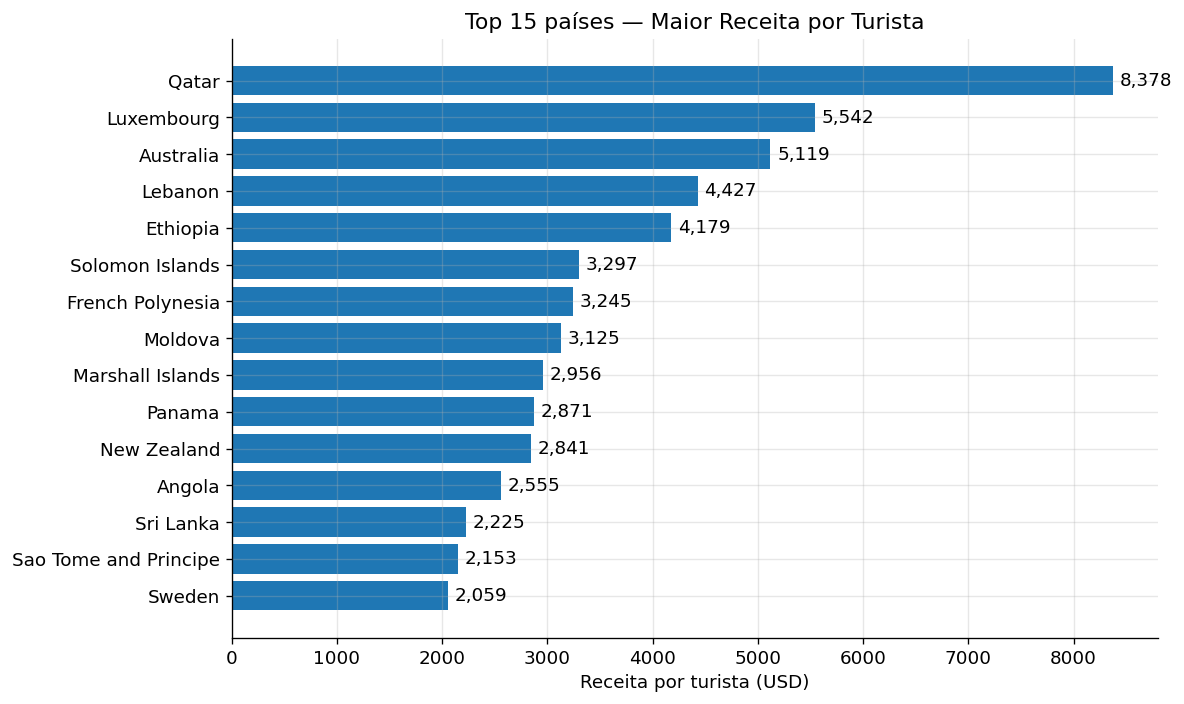


 A distribuição é fortemente assimétrica à direita — poucos países
   capturam receita muito elevada por visitante (geralmente turismo de luxo).


In [18]:
top_rec = last_year.nlargest(15, 'Receita_Turista')[['País', 'Receita_Turista']].reset_index(drop=True)
top_rec['Receita_Turista'] = top_rec['Receita_Turista'].round(0)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_rec['País'][::-1], top_rec['Receita_Turista'][::-1], color=PALETTE[0])
ax.set_xlabel('Receita por turista (USD)')
ax.set_title('Top 15 países — Maior Receita por Turista')
ax.bar_label(bars, fmt='{:,.0f}', padding=4)
plt.tight_layout()
plt.savefig('eda_01b_top_receita.png', bbox_inches='tight')
plt.show()

print("\n A distribuição é fortemente assimétrica à direita — poucos países")
print("   capturam receita muito elevada por visitante (geralmente turismo de luxo).")


## 3. Perfil por continente — volume vs. valor
**Pergunta:** Existem continentes com turismo mais voltado a volume ou valor?


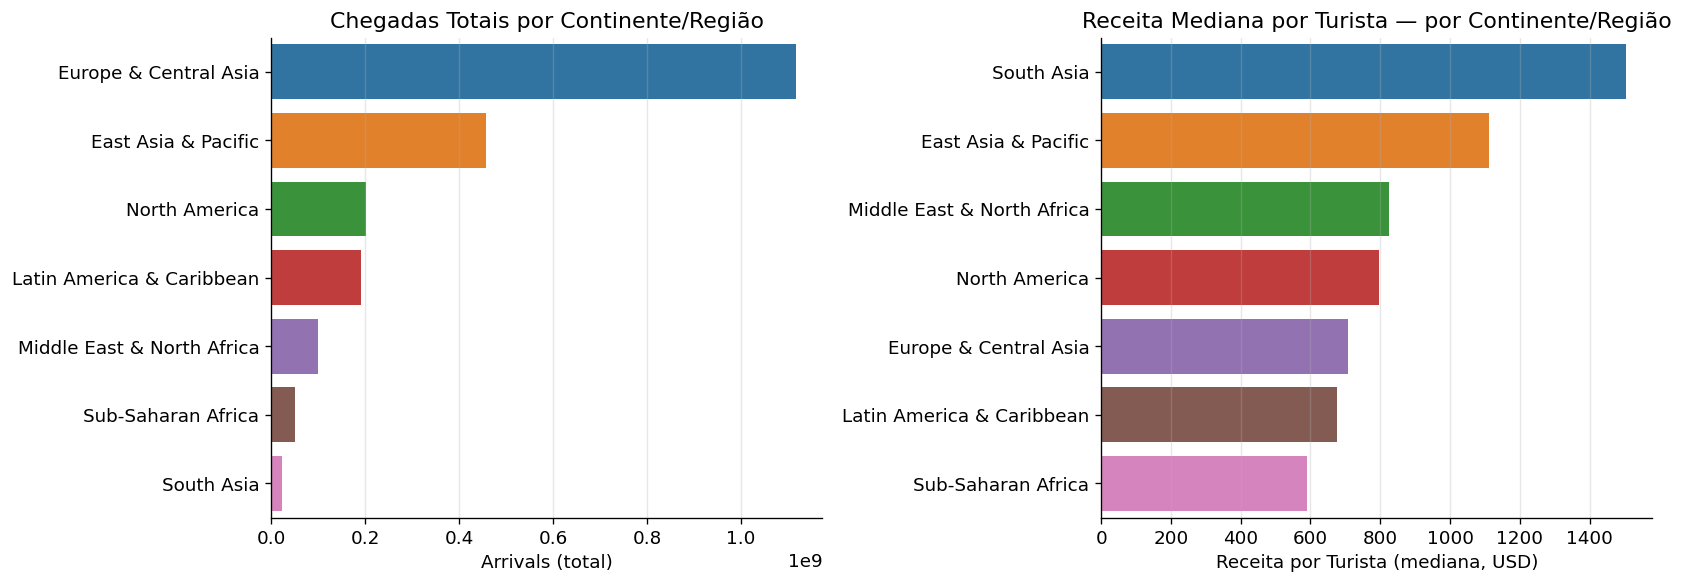

,Region,Arrivals_Total,Receita_Turista_Med,Turista_Habitante_Med,N_Paises
1,Europe & Central Asia,1.116748e+09,708.022207,1.549970,45
0,East Asia & Pacific,4.570650e+08,1110.556914,0.375705,28
4,North America,2.013649e+08,797.654193,0.843588,3
2,Latin America & Caribbean,1.905590e+08,677.179669,0.650809,33
3,Middle East & North Africa,9.984500e+07,824.380310,0.409459,16
6,Sub-Saharan Africa,5.111630e+07,589.191488,0.043430,36
5,South Asia,2.314200e+07,1504.876352,0.079055,6



Compare o ranking de volume vs. o ranking de valor —
continentes no topo em arrivals podem estar abaixo em receita/turista.


In [24]:
if 'Continent' in df.columns or 'Region' in df.columns:
    reg_col = 'Continent' if 'Continent' in df.columns else 'Region'
else:
    reg_col = None
    print("Coluna de continente/região não encontrada lol")

if reg_col:
    reg = (last_year.groupby(reg_col)
           .agg(
               Arrivals_Total=('Arrivals', 'sum'),
               Receita_Turista_Med=('Receita_Turista', 'median'),
               Turista_Habitante_Med=('Turista_Habitante', 'median'),
               N_Paises=('País', 'count')
           )
           .reset_index()
           .sort_values('Arrivals_Total', ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=reg, y=reg_col, x='Arrivals_Total', palette='tab10', ax=axes[0])
    axes[0].set_title('Chegadas Totais por Continente/Região')
    axes[0].set_xlabel('Arrivals (total)')
    axes[0].set_ylabel('')

    reg_sorted = reg.sort_values('Receita_Turista_Med', ascending=False)
    sns.barplot(data=reg_sorted, y=reg_col, x='Receita_Turista_Med', palette='tab10', ax=axes[1])
    axes[1].set_title('Receita Mediana por Turista — por Continente/Região')
    axes[1].set_xlabel('Receita por Turista (mediana, USD)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.savefig('eda_02_perfil_continente.png', bbox_inches='tight')
    plt.show()
    display(reg)
    print("\nCompare o ranking de volume vs. o ranking de valor —")
    print("continentes no topo em arrivals podem estar abaixo em receita/turista.")
else:
    print("Pulando análise por continente — coluna não encontrada.")


## 4. Balança turística global
**Pergunta:** Há mais países com superávit ou déficit turístico?


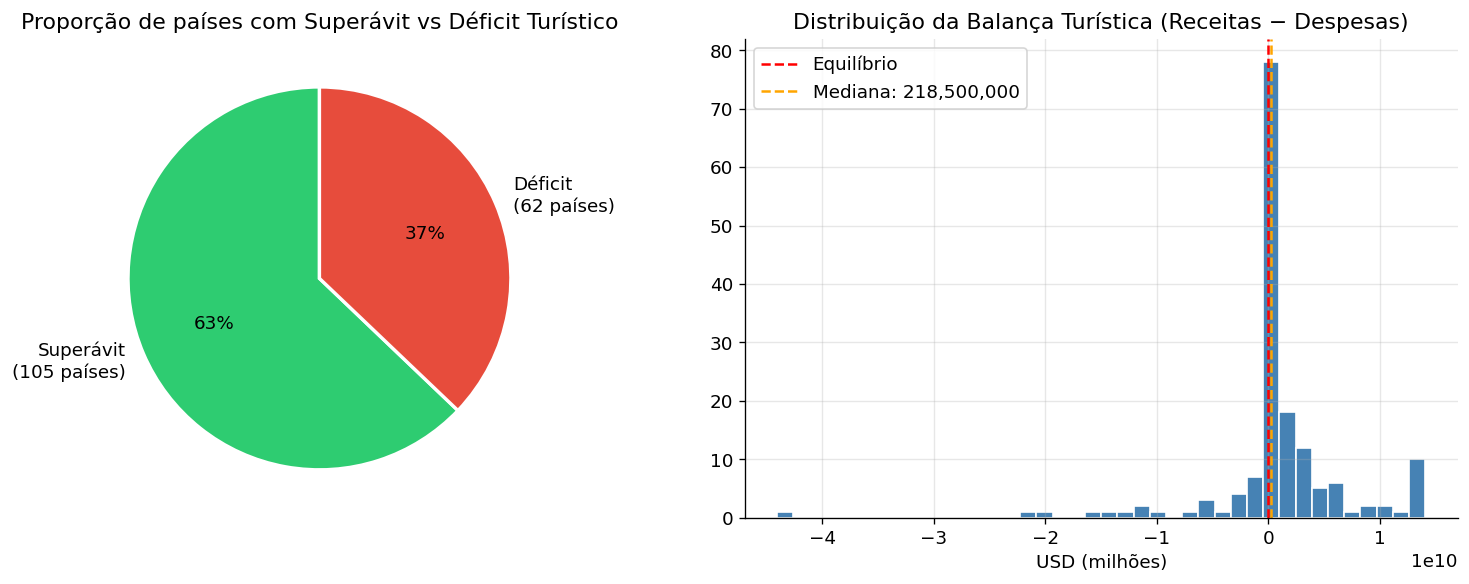


Países com SUPERÁVIT turístico: 105 (62.9%)
Países com DÉFICIT  turístico: 62 (37.1%)

A maioria dos países gasta mais em turismo externo do que recebe,
concentrando os superávits em poucos destinos líderes.


In [23]:
last_year['Superavit'] = last_year['Receita_menos_Despesas'] > 0

n_super = last_year['Superavit'].sum()
n_defic = (~last_year['Superavit']).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza (achei que seria bom pra mostrar a proporção)
axes[0].pie([n_super, n_defic],
            labels=[f'Superávit\n({n_super} países)', f'Déficit\n({n_defic} países)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporção de países com Superávit vs Déficit Turístico')

# Distribuição da balança
vals = last_year['Receita_menos_Despesas'].dropna()
axes[1].hist(vals.clip(upper=vals.quantile(0.95)), bins=40,
             color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equilíbrio')
axes[1].axvline(vals.median(), color='orange', linestyle='--',
                label=f'Mediana: {vals.median():,.0f}')
axes[1].set_title('Distribuição da Balança Turística (Receitas − Despesas)')
axes[1].set_xlabel('USD (milhões)')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_03_balanca.png', bbox_inches='tight')
plt.show()

print(f"\nPaíses com SUPERÁVIT turístico: {n_super} ({n_super/(n_super+n_defic)*100:.1f}%)")
print(f"Países com DÉFICIT  turístico: {n_defic} ({n_defic/(n_super+n_defic)*100:.1f}%)")
print("\nA maioria dos países gasta mais em turismo externo do que recebe,")
print("concentrando os superávits em poucos destinos líderes.")


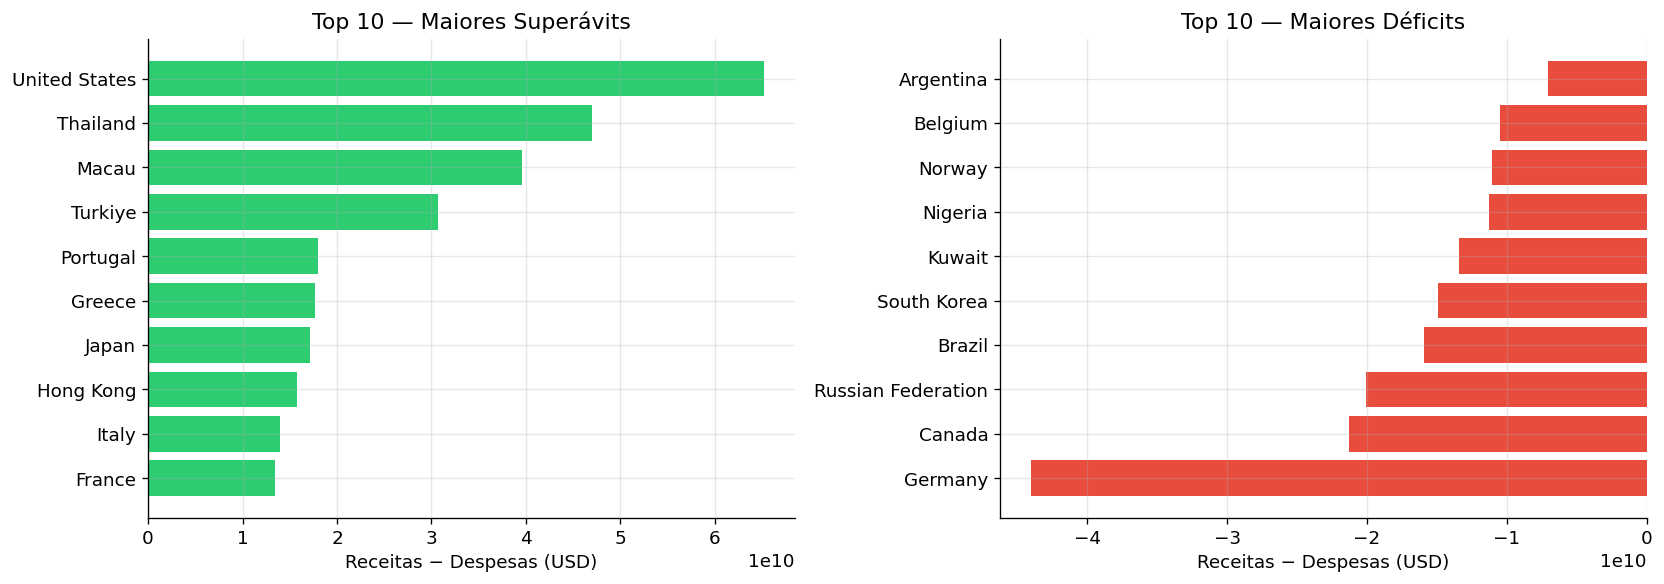

In [26]:
top_sup = last_year.nlargest(10, 'Receita_menos_Despesas')[['País', 'Receita_menos_Despesas']]
top_def = last_year.nsmallest(10, 'Receita_menos_Despesas')[['País', 'Receita_menos_Despesas']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_sup['País'][::-1], top_sup['Receita_menos_Despesas'][::-1], color='#2ecc71')
axes[0].set_title('Top 10 — Maiores Superávits')
axes[0].set_xlabel('Receitas − Despesas (USD)')

axes[1].barh(top_def['País'], top_def['Receita_menos_Despesas'], color='#e74c3c')
axes[1].set_title('Top 10 — Maiores Déficits')
axes[1].set_xlabel('Receitas − Despesas (USD)')

plt.tight_layout()
plt.savefig('eda_03b_top_balanca.png', bbox_inches='tight')
plt.show()


## 5. Crescimento — Arrivals e Receipts
**Perguntas:** Quais países mais cresceram? Crescimento de turistas implica crescimento de receita?


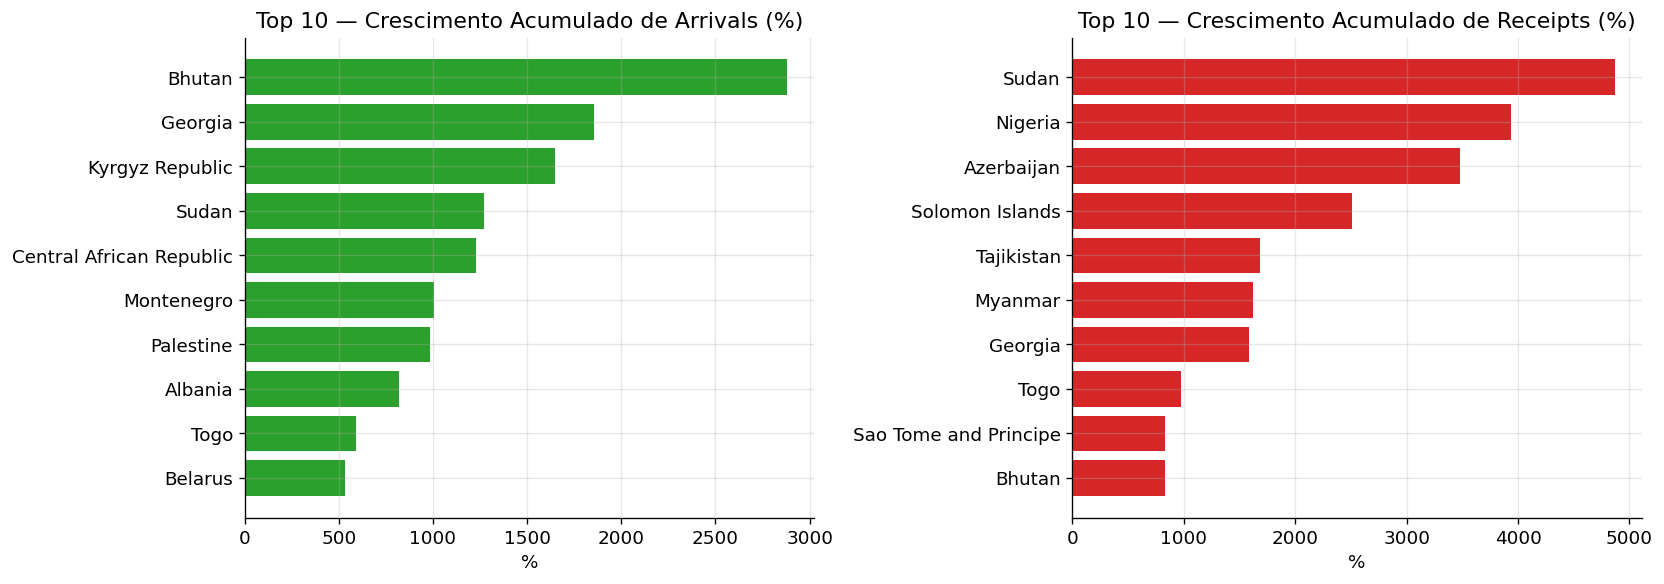

In [30]:
growth = (df.sort_values('Ano')
          .groupby('País')
          .last()
          .reset_index()[['País', 'Cresc_Acumulado_Arrivals', 'IncomeGroup'] if 'IncomeGroup' in df.columns else ['País', 'Cresc_Acumulado_Arrivals']]
         )

growth_rec = (df.sort_values('Ano')
              .groupby('País')
              .apply(lambda g: ((g['Receipts'].iloc[-1] - g['Receipts'].iloc[0]) / g['Receipts'].iloc[0]) * 100
                     if g['Receipts'].iloc[0] != 0 else np.nan)
              .reset_index(name='Cresc_Acumulado_Receipts'))

growth = growth.merge(growth_rec, on='País')

top10_arr = growth.nlargest(10, 'Cresc_Acumulado_Arrivals')[['País', 'Cresc_Acumulado_Arrivals']]
top10_rec = growth.nlargest(10, 'Cresc_Acumulado_Receipts')[['País', 'Cresc_Acumulado_Receipts']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top10_arr['País'][::-1], top10_arr['Cresc_Acumulado_Arrivals'][::-1], color=PALETTE[2])
axes[0].set_title('Top 10 — Crescimento Acumulado de Arrivals (%)')
axes[0].set_xlabel('%')

axes[1].barh(top10_rec['País'][::-1], top10_rec['Cresc_Acumulado_Receipts'][::-1], color=PALETTE[3])
axes[1].set_title('Top 10 — Crescimento Acumulado de Receipts (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.savefig('eda_04_crescimento_top10.png', bbox_inches='tight')
plt.show()


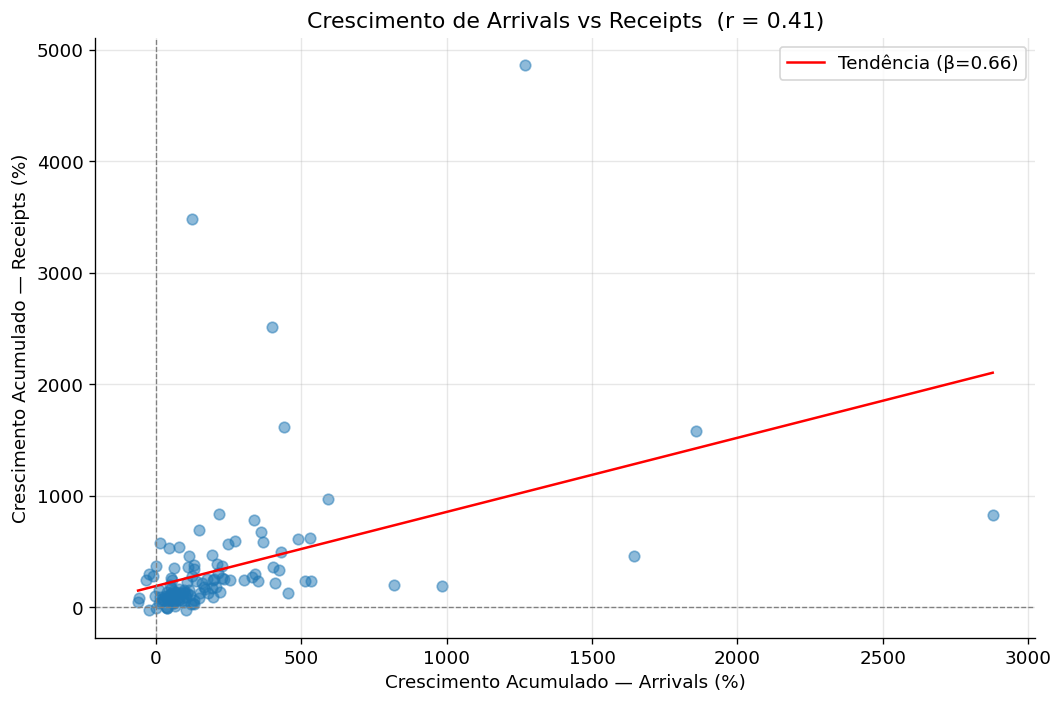

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    growth['Cresc_Acumulado_Arrivals'],
    growth['Cresc_Acumulado_Receipts'],
    alpha=0.5, s=40, color=PALETTE[0]
)

mask = growth[['Cresc_Acumulado_Arrivals', 'Cresc_Acumulado_Receipts']].notna().all(axis=1)
x = growth.loc[mask, 'Cresc_Acumulado_Arrivals']
y = growth.loc[mask, 'Cresc_Acumulado_Receipts']
if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs + b, color='red', linewidth=1.5, label=f'Tendência (β={m:.2f})')
    corr = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'Crescimento de Arrivals vs Receipts  (r = {corr:.2f})')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Crescimento Acumulado — Arrivals (%)')
ax.set_ylabel('Crescimento Acumulado — Receipts (%)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_04b_cresc_scatter.png', bbox_inches='tight')
plt.show()



## 6. Divergências — arrivals crescem, receitas não acompanham
Países onde o crescimento de chegadas é positivo mas a receita por turista caiu.


Países divergentes (arrivals crescem 2× mais que receipts): 16


,País,med_cresc_arr,med_cresc_rec,Divergente
30,Central African Republic,0.233431,0.080601,True
100,Montenegro,0.230178,0.063548,True
13,Belarus,0.223513,0.098048,True
69,Iceland,0.143174,0.035028,True
20,Bosnia and Herzegovina,0.132904,0.066155,True
144,Sweden,0.073362,0.028710,True
1,Algeria,0.064633,-0.047261,True
66,Honduras,0.063409,0.029085,True
38,Cuba,0.063290,0.024111,True
137,South Africa,0.059751,0.022503,True


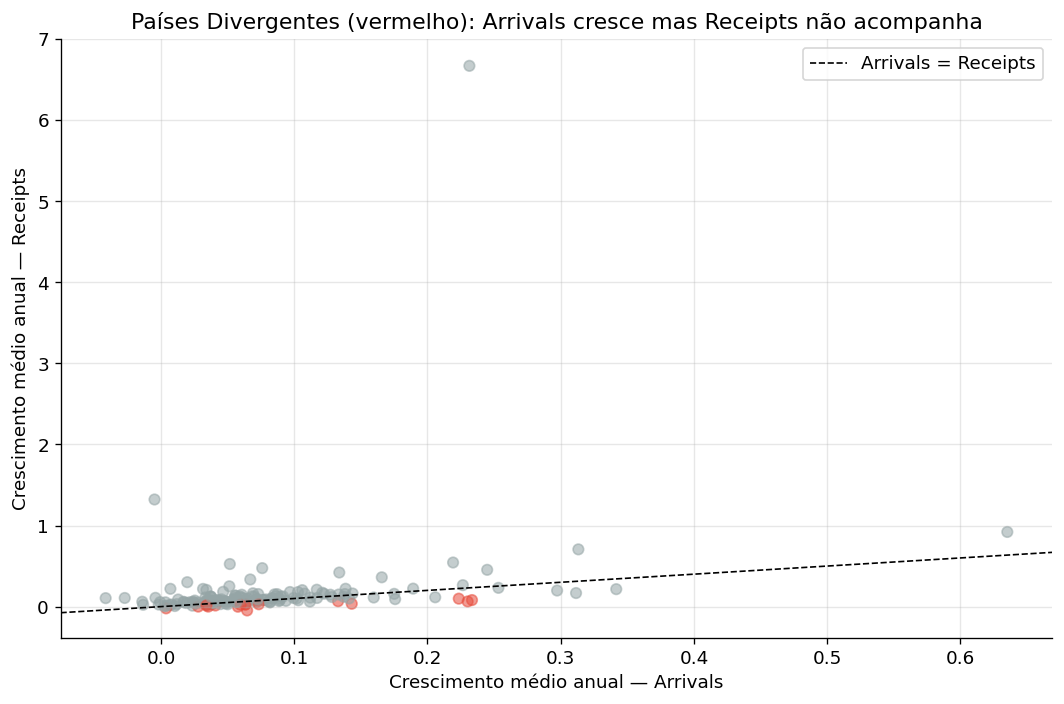

In [33]:
div = (df.groupby('País')
       .agg(
           med_cresc_arr=('Crescimento_Arrivals', 'mean'),
           med_cresc_rec=('Crescimento_Receipts', 'mean'),
       )
       .reset_index()
       .dropna()
      )

div['Divergente'] = (div['med_cresc_arr'] > 0) & (div['med_cresc_rec'] < div['med_cresc_arr'] * 0.5)

divergentes = div[div['Divergente']].sort_values('med_cresc_arr', ascending=False)
print(f"Países divergentes (arrivals crescem 2× mais que receipts): {len(divergentes)}")
display(divergentes.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if d else '#95a5a6' for d in div['Divergente']]
ax.scatter(div['med_cresc_arr'], div['med_cresc_rec'], alpha=0.55, s=40, c=colors)
ax.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1, label='Arrivals = Receipts')
ax.set_xlabel('Crescimento médio anual — Arrivals')
ax.set_ylabel('Crescimento médio anual — Receipts')
ax.set_title('Países Divergentes (vermelho): Arrivals cresce mas Receipts não acompanha')
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_divergentes.png', bbox_inches='tight')
plt.show()


## 7. Eficiência vs. Volume
**Pergunta:** Relação entre número de turistas e receita por turista.


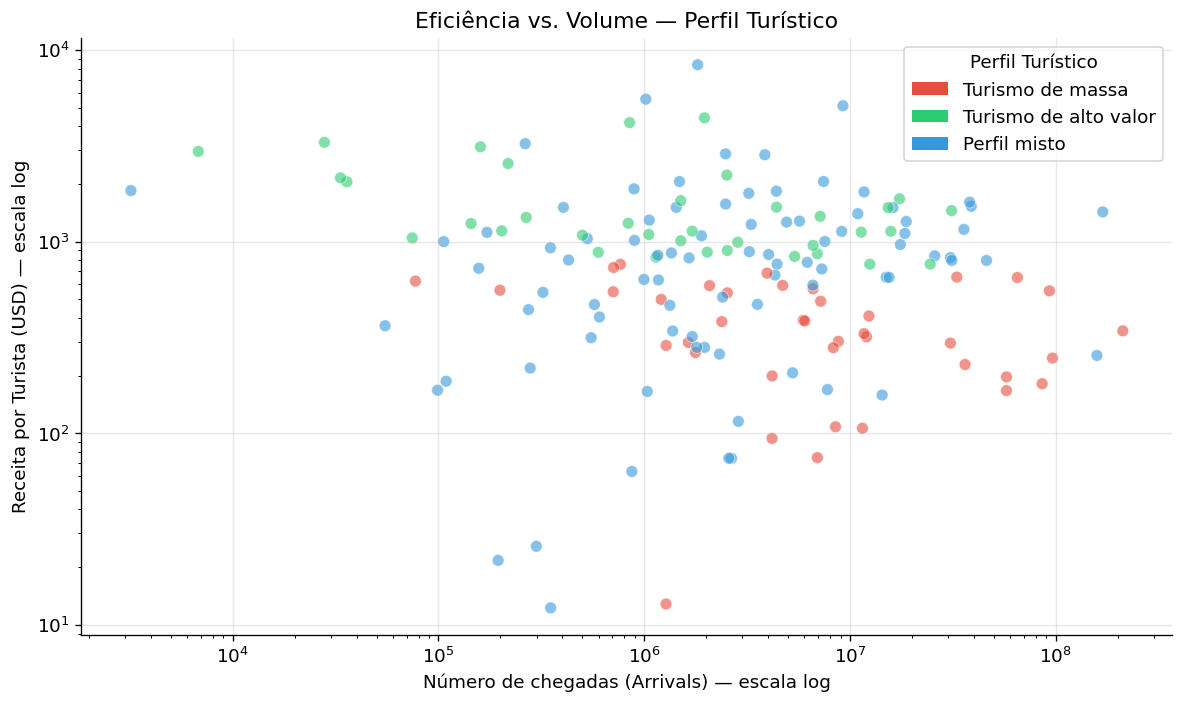


Contagem por perfil turístico:
Perfil_Turistico
Perfil misto             92
Turismo de massa         39
Turismo de alto valor    36

Países de alto volume tendem a ter menor receita por turista;
Países de alto valor atraem menos turistas mas monetizam melhor cada visita.


In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    last_year['Arrivals'],
    last_year['Receita_Turista'],
    c=last_year['Perfil_Turistico'].map({
        'Turismo de massa': '#e74c3c',
        'Turismo de alto valor': '#2ecc71',
        'Perfil misto': '#3498db'
    }),
    alpha=0.6, s=50, edgecolors='white', linewidths=0.5
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Turismo de massa'),
    Patch(facecolor='#2ecc71', label='Turismo de alto valor'),
    Patch(facecolor='#3498db', label='Perfil misto'),
]
ax.legend(handles=legend_elements, title='Perfil Turístico')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Número de chegadas (Arrivals) — escala log')
ax.set_ylabel('Receita por Turista (USD) — escala log')
ax.set_title('Eficiência vs. Volume — Perfil Turístico')
plt.tight_layout()
plt.savefig('eda_06_eficiencia_volume.png', bbox_inches='tight')
plt.show()

print("\nContagem por perfil turístico:")
print(last_year['Perfil_Turistico'].value_counts().to_string())
print("\nPaíses de alto volume tendem a ter menor receita por turista;")
print("Países de alto valor atraem menos turistas mas monetizam melhor cada visita.")


## 8. Intensidade turística — turistas por habitante
**Pergunta:** Quais países têm mais turistas por habitante?


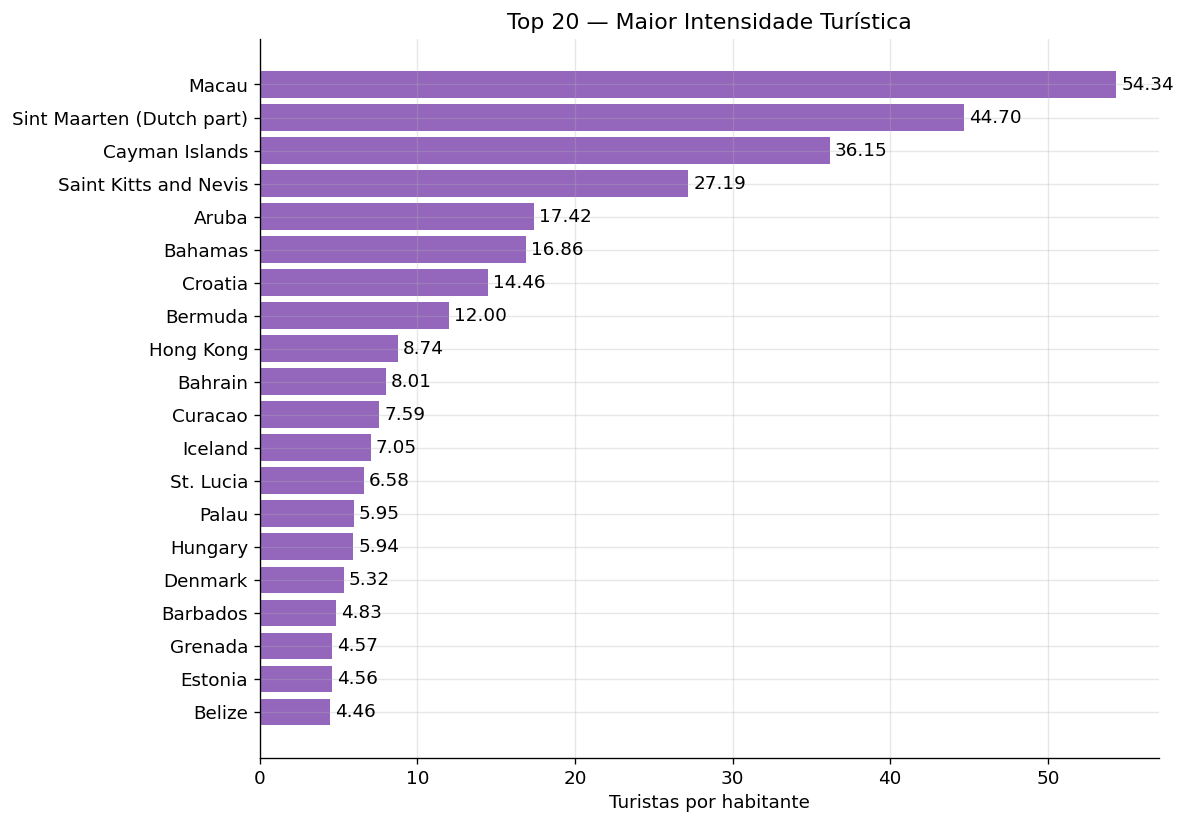


Estatísticas de Turista_Habitante:
count    167.0000
mean       2.4192
std        6.7873
min        0.0016
25%        0.0991
50%        0.4705
75%        1.5619
max       54.3390

Países pequenos (ilhas, cidades-estado) frequentemente
lideram — mais turistas do que residentes é comum em destinos de luxo.


In [37]:
top_intens = last_year.nlargest(20, 'Turista_Habitante')[['País', 'Turista_Habitante']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_intens['País'][::-1], top_intens['Turista_Habitante'][::-1], color=PALETTE[4])
ax.set_xlabel('Turistas por habitante')
ax.set_title('Top 20 — Maior Intensidade Turística')
ax.bar_label(bars, fmt='{:.2f}', padding=3)
plt.tight_layout()
plt.savefig('eda_07_intensidade.png', bbox_inches='tight')
plt.show()

print("\nEstatísticas de Turista_Habitante:")
print(last_year['Turista_Habitante'].describe().round(4).to_string())
print("\nPaíses pequenos (ilhas, cidades-estado) frequentemente")
print("lideram — mais turistas do que residentes é comum em destinos de luxo.")


## 9. Dependência econômica do turismo
**Pergunta:** Países mais dependentes do turismo — relação com IncomeGroup.


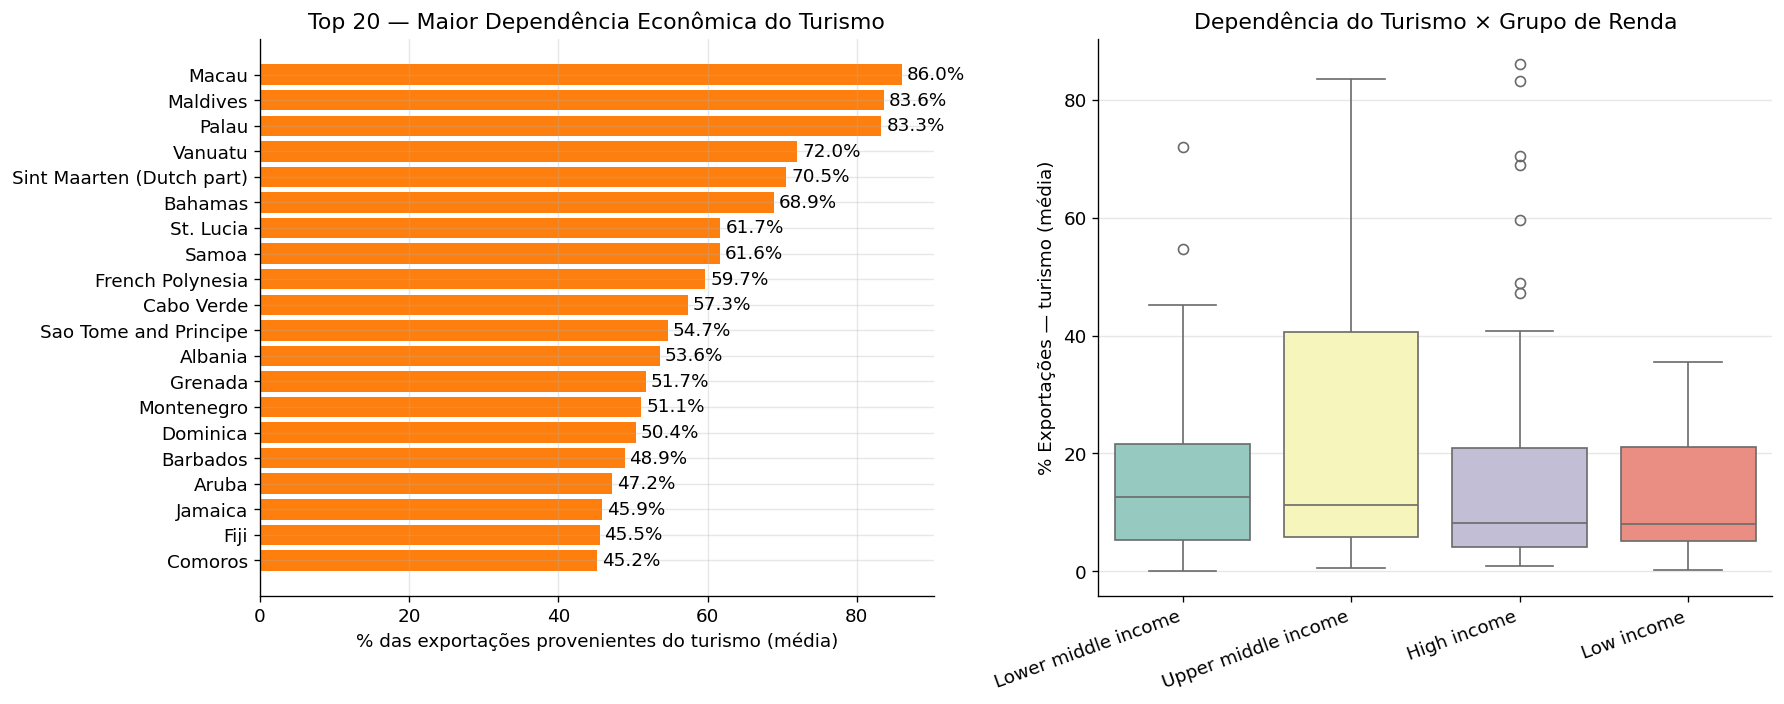


Países de renda baixa costumam ter alta dependência do turismo
como % das exportações — o que os torna vulneráveis a choques externos.


In [39]:
top_dep = last_year.nlargest(20, 'Dependencia_Media')[['País', 'Dependencia_Media']].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].barh(top_dep['País'][::-1], top_dep['Dependencia_Media'][::-1], color=PALETTE[1])
axes[0].set_xlabel('% das exportações provenientes do turismo (média)')
axes[0].set_title('Top 20 — Maior Dependência Econômica do Turismo')
axes[0].bar_label(bars, fmt='{:.1f}%', padding=3)

if 'IncomeGroup' in last_year.columns:
    order = (last_year.groupby('IncomeGroup')['Dependencia_Media']
             .median().sort_values(ascending=False).index)
    sns.boxplot(data=last_year, x='IncomeGroup', y='Dependencia_Media',
                order=order, palette='Set3', ax=axes[1])
    axes[1].set_title('Dependência do Turismo × Grupo de Renda')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('% Exportações — turismo (média)')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Coluna IncomeGroup não encontrada',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('eda_08_dependencia.png', bbox_inches='tight')
plt.show()

print("\nPaíses de renda baixa costumam ter alta dependência do turismo")
print("como % das exportações — o que os torna vulneráveis a choques externos.")


## 10. Estabilidade — volatilidade de Arrivals
**Pergunta:** Quais países têm maior volatilidade no turismo?


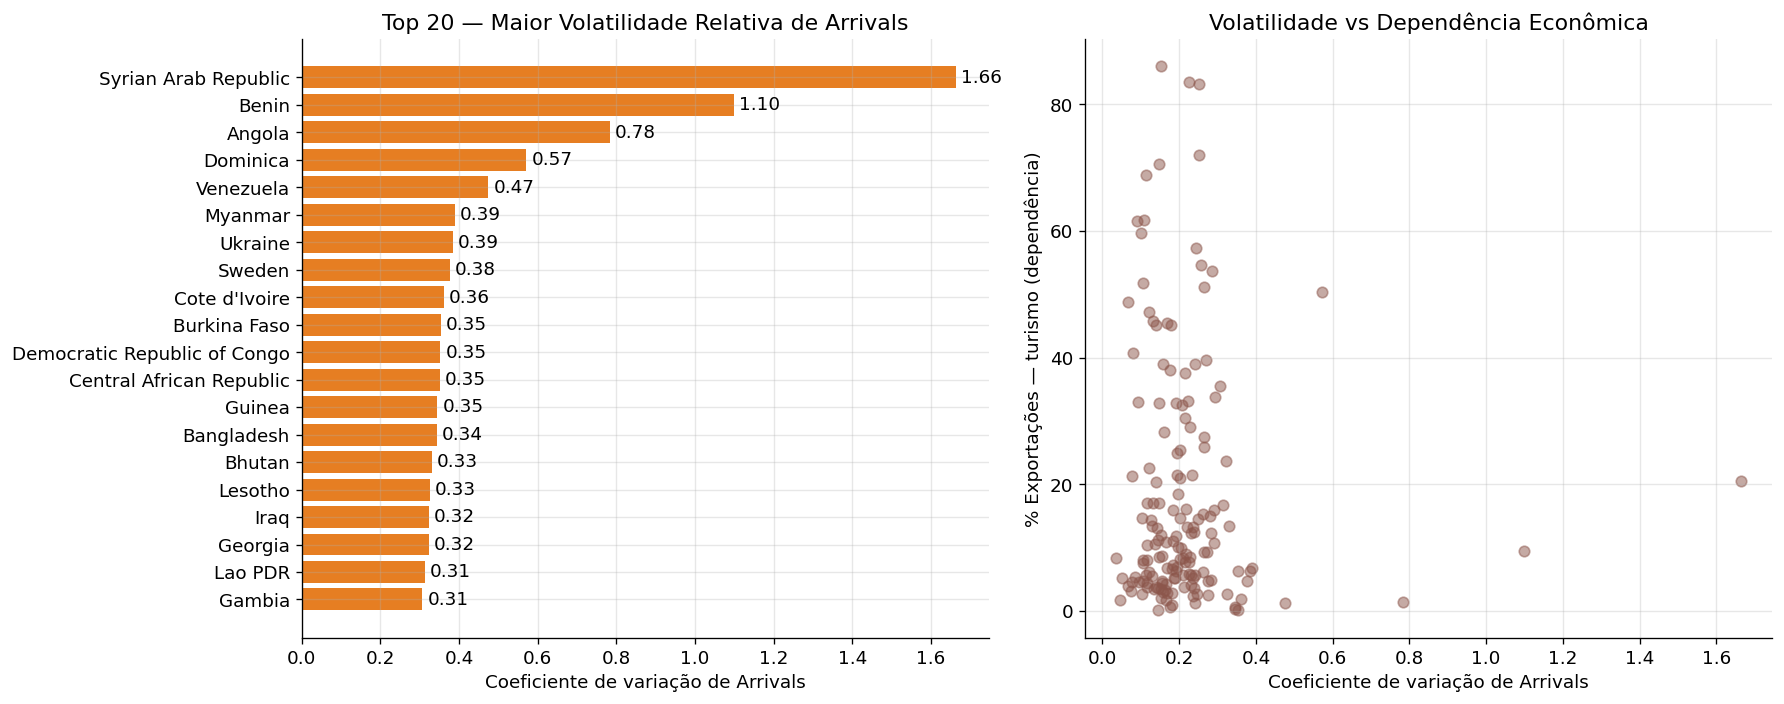


Países muito dependentes do turismo e altamente voláteis
representam o maior risco macroeconômico, por ex: pequenas ilhas afetadas
por crises (pandemia, desastres naturais).


In [42]:
vol = (last_year[['País', 'Volatilidade_Arrivals', 'Arrivals']]
       .dropna()
       .copy())
vol['Vol_Relativa'] = vol['Volatilidade_Arrivals'] / vol['Arrivals']  # Coef. de variação aproximado

top_vol = vol.nlargest(20, 'Vol_Relativa')[['País', 'Vol_Relativa']].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].barh(top_vol['País'][::-1], top_vol['Vol_Relativa'][::-1], color='#e67e22')
axes[0].set_xlabel('Coeficiente de variação de Arrivals')
axes[0].set_title('Top 20 — Maior Volatilidade Relativa de Arrivals')
axes[0].bar_label(bars, fmt='{:.2f}', padding=3)

merged = vol.merge(last_year[['País', 'Dependencia_Media']], on='País', how='left')
axes[1].scatter(merged['Vol_Relativa'], merged['Dependencia_Media'],
                alpha=0.5, s=40, color=PALETTE[5])
axes[1].set_xlabel('Coeficiente de variação de Arrivals')
axes[1].set_ylabel('% Exportações — turismo (dependência)')
axes[1].set_title('Volatilidade vs Dependência Econômica')

plt.tight_layout()
plt.savefig('eda_09_volatilidade.png', bbox_inches='tight')
plt.show()

print("\nPaíses muito dependentes do turismo e altamente voláteis")
print("representam o maior risco macroeconômico, por ex: pequenas ilhas afetadas")
print("por crises (pandemia, desastres naturais).")


## 11. Matriz de correlação entre variáveis de FE
**Pergunta:** Relações entre crescimento, intensidade e eficiência.


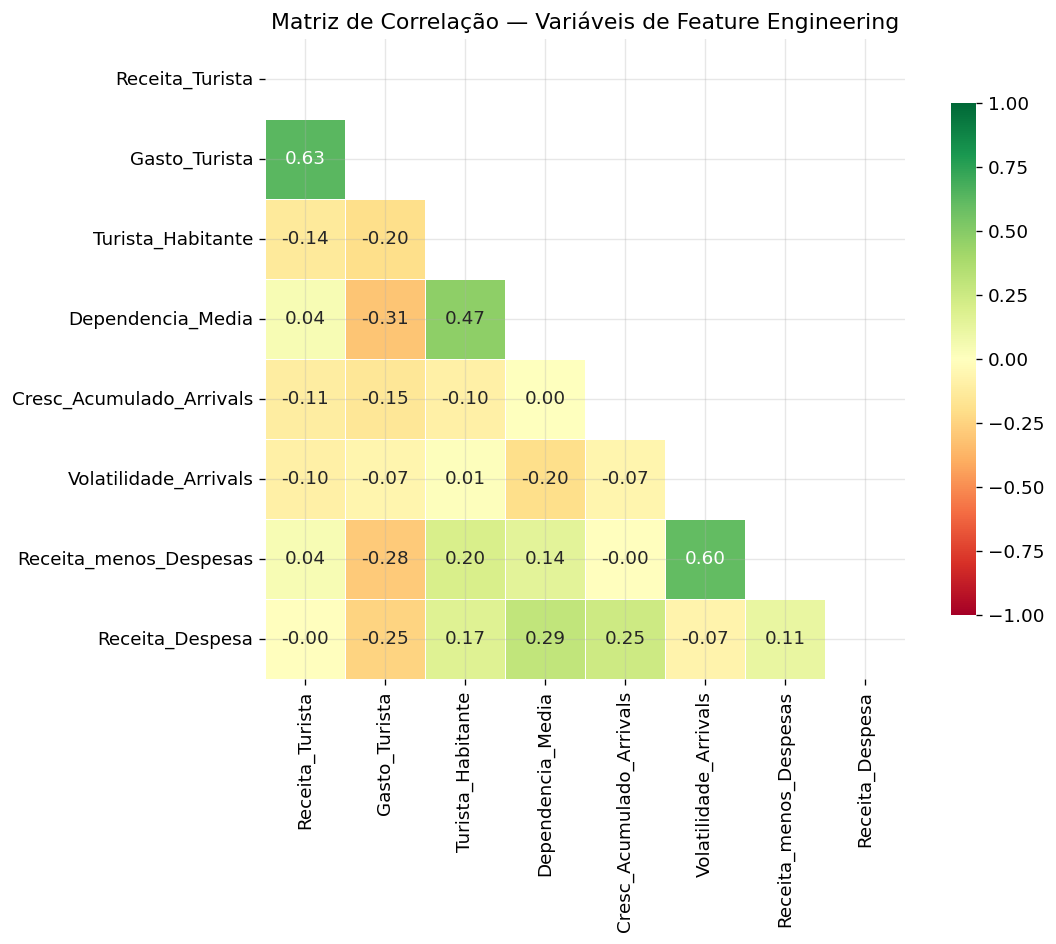


Correlações mais fortes (|r| > 0.5):


,Var1,Var2,r
0,Gasto_Turista,Receita_Turista,0.626713
1,Receita_menos_Despesas,Volatilidade_Arrivals,0.602743


In [44]:
corr_cols = [
    'Receita_Turista', 'Gasto_Turista', 'Turista_Habitante',
    'Dependencia_Media', 'Cresc_Acumulado_Arrivals',
    'Volatilidade_Arrivals', 'Receita_menos_Despesas', 'Receita_Despesa'
]

corr_df = last_year[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação — Variáveis de Feature Engineering')
plt.tight_layout()
plt.savefig('eda_10_correlacao.png', bbox_inches='tight')
plt.show()

print("\nCorrelações mais fortes (|r| > 0.5):")
corr_pairs = (corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack()
              .reset_index()
              .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'r'}))
strong = corr_pairs[corr_pairs['r'].abs() > 0.5].sort_values('r', key=abs, ascending=False)
if len(strong):
    display(strong.reset_index(drop=True))
else:
    print("Nenhuma correlação forte encontrada acima de |r|=0.5 neste dataset.")


## 12. Evolução temporal global
Tendência agregada de Arrivals e Receipts ao longo dos anos.


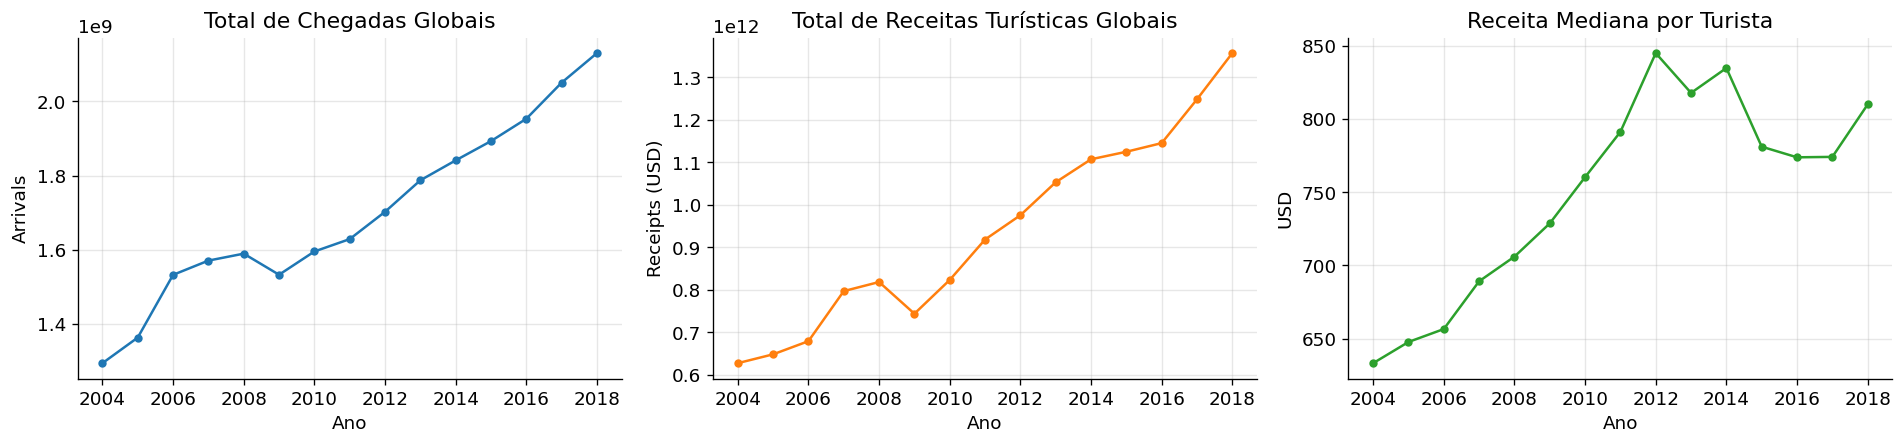


É possível observar uma queda em 2009, provavelmente causada pela
Crise do subprime, que teve seu auge no segundo semestre de 2008.


In [48]:
ts = df.groupby('Ano').agg(
    Total_Arrivals=('Arrivals', 'sum'),
    Total_Receipts=('Receipts', 'sum'),
    Receita_Turista_Med=('Receita_Turista', 'median')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ts['Ano'], ts['Total_Arrivals'], marker='o', markersize=4, color=PALETTE[0])
axes[0].set_title('Total de Chegadas Globais')
axes[0].set_ylabel('Arrivals')

axes[1].plot(ts['Ano'], ts['Total_Receipts'], marker='o', markersize=4, color=PALETTE[1])
axes[1].set_title('Total de Receitas Turísticas Globais')
axes[1].set_ylabel('Receipts (USD)')

axes[2].plot(ts['Ano'], ts['Receita_Turista_Med'], marker='o', markersize=4, color=PALETTE[2])
axes[2].set_title('Receita Mediana por Turista')
axes[2].set_ylabel('USD')

for ax in axes:
    ax.set_xlabel('Ano')

plt.tight_layout()
plt.savefig('eda_11_serie_temporal.png', bbox_inches='tight')
plt.show()

print("\nÉ possível observar uma queda em 2009, provavelmente causada pela")
print("Crise do subprime, que teve seu auge no segundo semestre de 2008.")


## 13. Mapa — Receita por Turista (geopandas)
Visualização geoespacial da distribuição de receita por turista.


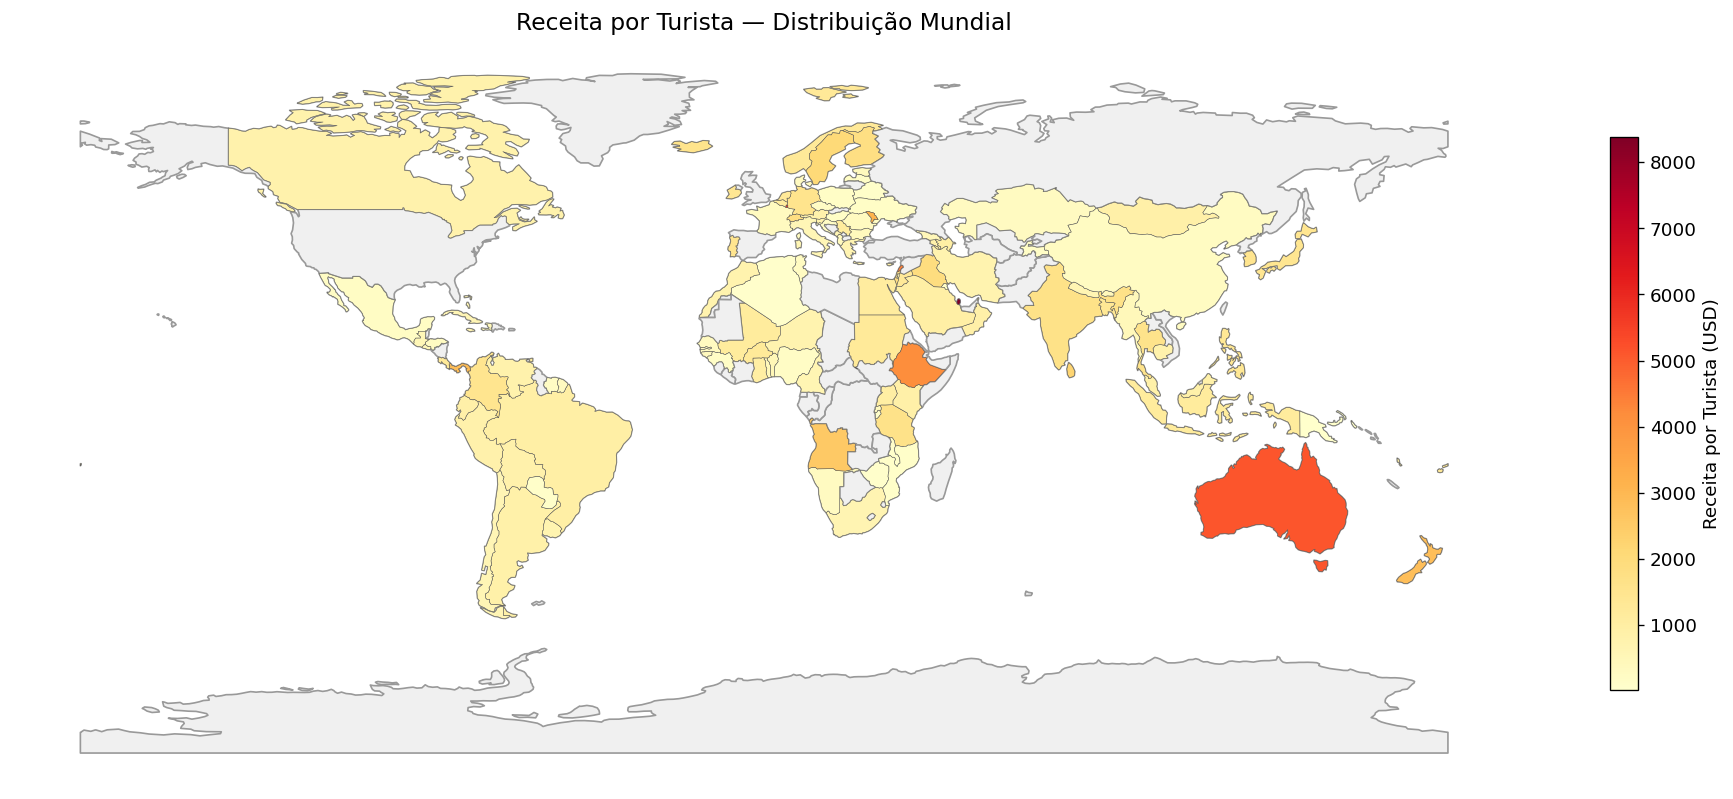

Países com dado no mapa: 120 / 177


In [52]:
if HAS_GEO:
    SHAPEFILE = '/usr/local/lib/python3.12/dist-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp'
    try:
        world = gpd.read_file(SHAPEFILE)
        merged_geo = world.merge(last_year, left_on='name', right_on='País', how='left')

        fig, ax = plt.subplots(figsize=(16, 8))
        world.plot(ax=ax, color='#f0f0f0', edgecolor='#999')
        merged_geo.dropna(subset=['Receita_Turista']).plot(
            ax=ax, column='Receita_Turista', legend=True,
            cmap='YlOrRd', edgecolor='#555', linewidth=0.3,
            legend_kwds={'label': 'Receita por Turista (USD)', 'shrink': 0.6}
        )
        ax.set_title('Receita por Turista — Distribuição Mundial', fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig('eda_12_mapa_receita.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f"Países com dado no mapa: {merged_geo['Receita_Turista'].notna().sum()} / {len(world)}")
    except Exception as e:
        print(f"Erro ao gerar mapa: {e}")
else:
    print("Geopandas não disponível, instale usando pip.")


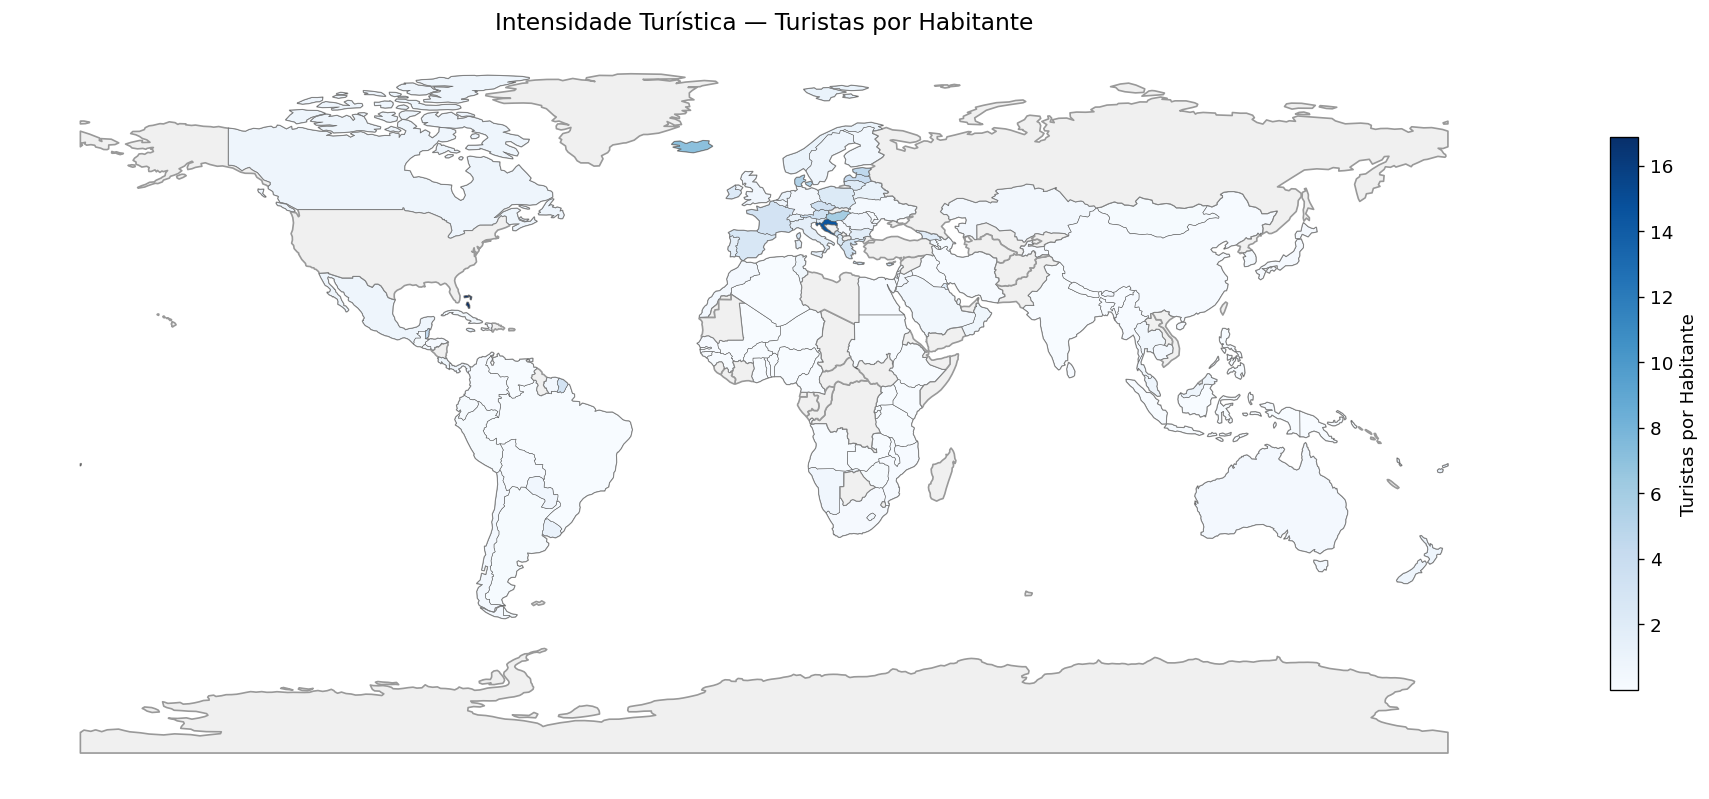

In [53]:
if HAS_GEO:
    try:
        merged_geo2 = world.merge(last_year, left_on='name', right_on='País', how='left')
        fig, ax = plt.subplots(figsize=(16, 8))
        world.plot(ax=ax, color='#f0f0f0', edgecolor='#999')
        merged_geo2.dropna(subset=['Turista_Habitante']).plot(
            ax=ax, column='Turista_Habitante', legend=True,
            cmap='Blues', edgecolor='#555', linewidth=0.3,
            legend_kwds={'label': 'Turistas por Habitante', 'shrink': 0.6}
        )
        ax.set_title('Intensidade Turística — Turistas por Habitante', fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig('eda_12b_mapa_intensidade.png', bbox_inches='tight', dpi=150)
        plt.show()
    except Exception as e:
        print(f"Erro ao gerar mapa de intensidade: {e}")


In [56]:
df.to_csv('Tourism Quantity Data Analyzed.csv', index=False)